In [1]:
import torch
import warnings
warnings.filterwarnings("ignore")
from main import GPTModel

/Users/himmat/LLM-from-Scratch/.venv/lib/python3.12/site-packages/torch/_subclasses/functional_tensor.py:368: UserWarning: Failed to initialize NumPy: No module named 'numpy' (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:84.)
  cpu = _conversion_method_template(device=torch.device("cpu"))


In [2]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 256,
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.1,
    "qkv_bias": False
}

In [3]:
torch.manual_seed(123)

In [4]:
model = GPTModel(GPT_CONFIG_124M)
model.eval();

In [5]:
import tiktoken

def text_to_token(text, tokenizer):
    encode = tokenizer.encode(text)
    encoded_tensor = torch.tensor(encode).unsqueeze(0) # Add a batch dimensions
    return encoded_tensor

In [6]:
context = "Hello, how are you"
tokenizer = tiktoken.get_encoding('gpt2')
token = text_to_token(context, tokenizer)
token

tensor([[15496,    11,   703,   389,   345]])

In [7]:
def token_to_text(token, tokenizer):
    decode = token.squeeze(0) # Removing batch dimensions
    text = tokenizer.decode(decode.tolist()) # converting tensors into list
    return text

In [8]:
token_to_text(token, tokenizer)

'Hello, how are you'

In [9]:
from main import GenerateSimpleText

token_ids = GenerateSimpleText(model, text_to_token(context, tokenizer), max_num_token=10, context_size=256)
token_ids.squeeze(0)

tensor([15496,    11,   703,   389,   345, 30057,  6287,  5286, 46073, 17822,
        34494, 12250, 32013,  7165, 34341])

In [10]:
token_to_text(token_ids, tokenizer)

'Hello, how are you261 extentaded EngelLab shave neighbour finalized crazy Roots'

## Calculating text generation loss: cross-entropy and perplexity

In [11]:
with open("the-verdict.txt", 'r') as f:
    text_data = f.read()

In [12]:
print(len(text_data))
print(len(tokenizer.encode(text_data)))

20479
5145


In [13]:
train_ration = 0.9
split = int(train_ration * len(text_data))
train_data = text_data[:split]
test_data = text_data[split:]

In [14]:
from main import create_dataloader_v1

In [15]:
torch.manual_seed(123)

In [16]:
train_data_loader = create_dataloader_v1(
    train_data, 2, GPT_CONFIG_124M['context_length'], stride=GPT_CONFIG_124M['context_length'], shuffle=True, drop_last=True, num_workers=0
)

val_data_loader = create_dataloader_v1(
    test_data, 2, GPT_CONFIG_124M['context_length'], stride=GPT_CONFIG_124M['context_length'], shuffle=False, drop_last=False, num_workers=0
)

In [17]:
for x, y in train_data_loader:
    print(x.shape, y.shape)

torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])


In [18]:
train_token = 0
for x, y in train_data_loader:
    train_token += x.numel()

test_token = 0
for x, y in val_data_loader:
    test_token += x.numel()

print("Train Token", train_token)
print("Test token", test_token)
print("Total token", train_token + test_token)

Train Token 4608
Test token 512
Total token 5120


In [27]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss

def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float('nan')
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))

    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

In [29]:
with torch.no_grad():
    training_loss = calc_loss_loader(train_data_loader, model, device="mps")
    val_loss = calc_loss_loader(val_data_loader, model, device="mps")

print("Training Loss: ", training_loss)
print("Val Loss: ", val_loss)

Training Loss:  10.977220111423069
Val Loss:  10.988805770874023


In [30]:
device = "mps" if torch.mps.is_available() else "cpu"

In [31]:
def train_model_simple(model, train_loader, val_loader, optimizer, num_epochs, eval_freq, eval_iter, start_context, tokeinzer, device):
    train_losses, val_losses, track_token_seen = [], [], []
    token_seen, global_step = 0, -1

    for epoch in range(num_epochs):
        model.train()

        for input_batch, target_batch, in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()
            optimizer.step()
            token_seen += input_batch.numel()
            global_step += 1

            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_token_seen.append(token_seen)
                print(f"Ep {epoch + 1} (Step {global_step:06d}): ", f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

            generate_and_print_simple_text(
                model, tokeinzer, device, start_context
            )

    return train_losses, val_losses, track_token_seen

def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss

def generate_and_print_simple_text(model, tokenizer, device, start_contxt):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token(start_contxt, tokenizer).to(device)
    with torch.no_grad():
        token_ids = GenerateSimpleText(model, encoded, 50, context_size=context_size)
    decoded_text = token_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))
    model.train()

In [32]:
model = GPTModel(GPT_CONFIG_124M).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

In [34]:
num_epochs = 10
train_losses, val_losses, track_token_seen = train_model_simple(
    model=model, train_loader=train_data_loader, val_loader=val_data_loader, optimizer= optimizer,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5, start_context="Every efforts moves you", tokeinzer=tokenizer, device=device
)

Ep 1 (Step 000000):  Train loss 9.873, Val loss 10.059
Every efforts moves you,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Every efforts moves you,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Every efforts moves you,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Every efforts moves you,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Every efforts moves you,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Ep 1 (Step 000005):  Train loss 8.033, Val loss 8.380
Every efforts moves you, the,,,,,, the,, the, the,, the, the,,,, the,, the, the, the, the, the, the,, the, the, the,, the,, the
Every efforts moves you,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Every efforts moves you,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Every efforts moves you,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Every efforts moves you                                                  
Ep 2 (Step 000010):  Train loss 6.706, Val loss 7.090
Every efforts moves you                    

In [37]:
track_token_seen

[512,
 3072,
 5632,
 8192,
 10752,
 13312,
 15872,
 18432,
 20992,
 23552,
 26112,
 28672,
 31232,
 33792,
 36352,
 38912,
 41472,
 44032]

In [39]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

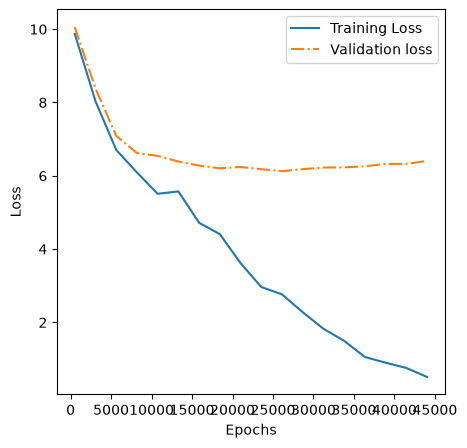

In [44]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(track_token_seen, train_losses, label="Training Loss")
ax.plot(track_token_seen, val_losses, linestyle="-.", label="Validation loss")
ax.set_xlabel("Epochs")
ax.set_ylabel("Loss")
ax.legend(loc='upper right')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))